Import libraries

In [1]:
pip install matplotlib

  Using cached matplotlib-3.11.0-cp314-cp314-win_amd64.whl.metadata (80 kB)
  Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp314-cp314-win_amd64.whl.metadata (121 kB)
  Using cached kiwisolver-1.5.0-cp314-cp314-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.3.0-cp314-cp314-win_amd64.whl.metadata (9.3 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.11.0-cp314-cp314-win_amd64.whl (9.5 MB)
Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl (232 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.63.0-cp314-cp314-win_amd64.whl (2.3 MB)
Using cached kiwisolver-1.5.0-cp314-cp314-win_amd64.whl (75 kB)
Using cached pillow-12.3.0-cp314-cp314-win_amd64.whl (7.2 MB)
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)

   ---------------------------------------- 0/7 [pyparsing]
   -


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

loading dataset 

In [3]:
df = pd.read_csv("VG Sales Dataset.csv")

Explore the dataset
- Checking the column names
- The data info
- Data description 

In [4]:
print(df.head())

print(df.info())

print(df.describe(include='all'))

print(df.shape)

   Rank                      Name Platform    Year         Genre Publisher  \
0     1                Wii Sports      Wii  2006.0        Sports  Nintendo   
1     2         Super Mario Bros.      NES  1985.0      Platform  Nintendo   
2     3            Mario Kart Wii      Wii  2008.0        Racing  Nintendo   
3     4         Wii Sports Resort      Wii  2009.0        Sports  Nintendo   
4     5  Pokemon Red/Pokemon Blue       GB  1996.0  Role-Playing  Nintendo   

   NA_Sales  EU_Sales  JP_Sales  Other_Sales  Global_Sales  
0     41.49     29.02      3.77         8.46         82.74  
1       NaN      3.58      6.81         0.77         40.24  
2     15.85       NaN      3.79         3.31         35.82  
3     15.75     11.01       NaN         2.96         33.00  
4     11.27      8.89     10.22          NaN         31.37  
<class 'pandas.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        -----

Checking data type

In [5]:
print(df.dtypes)

Rank              int64
Name                str
Platform            str
Year            float64
Genre               str
Publisher           str
NA_Sales        float64
EU_Sales        float64
JP_Sales        float64
Other_Sales     float64
Global_Sales    float64
dtype: object


In [6]:
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')

 Missing values (Count and Percentage)

In [7]:
missing = df.isnull().sum()

missing_percent = (missing/len(df))*100

missing_df = pd.DataFrame({
    "Missing Values": missing,
    "Percentage (%)": missing_percent.round(2)
})

print(missing_df.sort_values("Percentage (%)", ascending=False))

              Missing Values  Percentage (%)
Year                     271            1.63
Publisher                 58            0.35
NA_Sales                   3            0.02
Global_Sales               3            0.02
Other_Sales                3            0.02
EU_Sales                   3            0.02
JP_Sales                   2            0.01
Platform                   0            0.00
Name                       0            0.00
Rank                       0            0.00
Genre                      0            0.00


In [ ]:
Visualize missing values

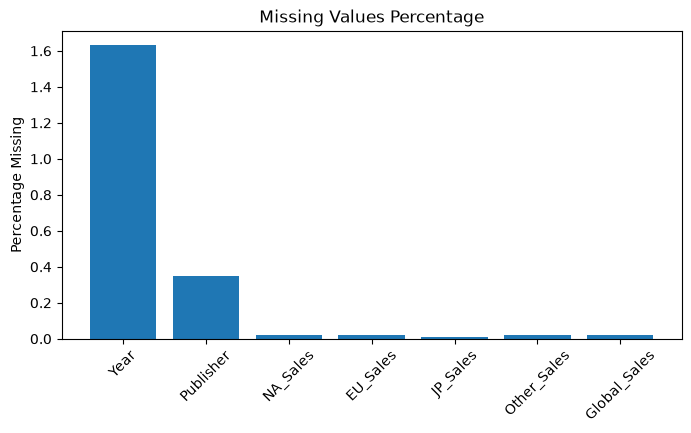

In [8]:
missing_df = missing_df[missing_df["Missing Values"] > 0]

plt.figure(figsize=(8,4))
plt.bar(missing_df.index, missing_df["Percentage (%)"])
plt.xticks(rotation=45)
plt.ylabel("Percentage Missing")
plt.title("Missing Values Percentage")
plt.show()

Handle missing values

In [9]:
# Year
df['Year'].fillna(df['Year'].median(), inplace=True)

# Publisher
df['Publisher'].fillna(df['Publisher'].mode()[0], inplace=True)

# Sales columns
sales_cols = [
    'NA_Sales',
    'EU_Sales',
    'JP_Sales',
    'Other_Sales',
    'Global_Sales'
]

for col in sales_cols:
    df[col].fillna(df[col].median(), inplace=True)

C:\Users\LIZZY\AppData\Local\Temp\ipykernel_19248\2245754254.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Year'].fillna(df['Year'].median(), inplace=True)
C:\Users\LIZZY\AppData\Local\Temp\ipykernel_19248\2245754254.py:5: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assign

Checking duplicates

In [10]:
duplicates = df.duplicated().sum()

print("Duplicate rows:", duplicates)

Duplicate rows: 0


In [ ]:
Removing the duplicates 

In [12]:
df = df.drop_duplicates()

In [13]:
print((df[sales_cols] < 0).sum())

NA_Sales        0
EU_Sales        0
JP_Sales        0
Other_Sales     0
Global_Sales    0
dtype: int64


checking for Outliers 

C:\Users\LIZZY\AppData\Local\Temp\ipykernel_19248\871769057.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col], vert=False)


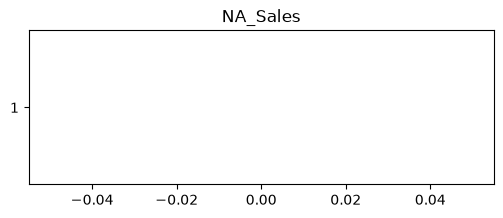

C:\Users\LIZZY\AppData\Local\Temp\ipykernel_19248\871769057.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col], vert=False)


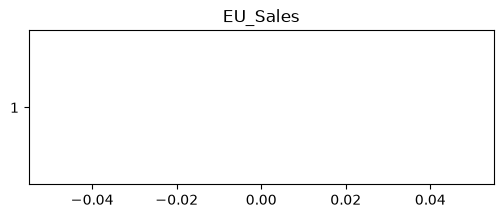

C:\Users\LIZZY\AppData\Local\Temp\ipykernel_19248\871769057.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col], vert=False)


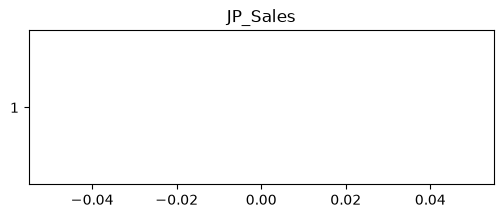

C:\Users\LIZZY\AppData\Local\Temp\ipykernel_19248\871769057.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col], vert=False)


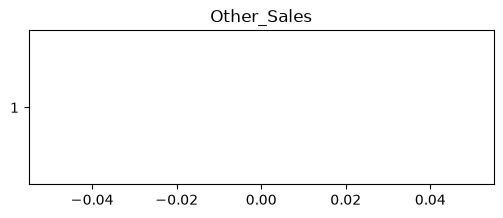

C:\Users\LIZZY\AppData\Local\Temp\ipykernel_19248\871769057.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col], vert=False)


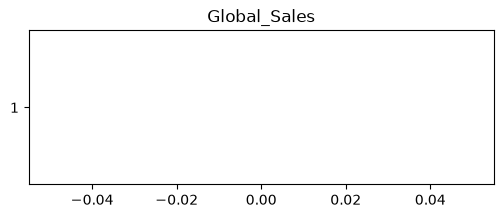

In [14]:
for col in sales_cols:

    plt.figure(figsize=(6,2))

    plt.boxplot(df[col], vert=False)

    plt.title(col)

    plt.show()

Detect outliers using IQR

In [15]:
for col in sales_cols:

    Q1 = df[col].quantile(.25)
    Q3 = df[col].quantile(.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}")
    print(f"Number of outliers: {len(outliers)}")

NA_Sales
Number of outliers: 1679
EU_Sales
Number of outliers: 2079
JP_Sales
Number of outliers: 2424
Other_Sales
Number of outliers: 1663
Global_Sales
Number of outliers: 1891


Handling outliers

In [16]:
for col in sales_cols:

    Q1 = df[col].quantile(.25)
    Q3 = df[col].quantile(.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    df[col] = df[col].clip(lower, upper)

In [18]:
for col in sales_cols:

    df[col+"_log"] = np.log1p(df[col])

Distribution of Global Sales

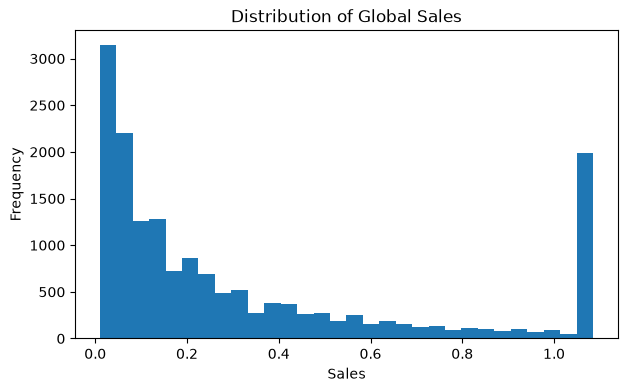

In [19]:
plt.figure(figsize=(7,4))

plt.hist(df["Global_Sales"], bins=30)

plt.title("Distribution of Global Sales")

plt.xlabel("Sales")

plt.ylabel("Frequency")

plt.show()

Average Sales by Year

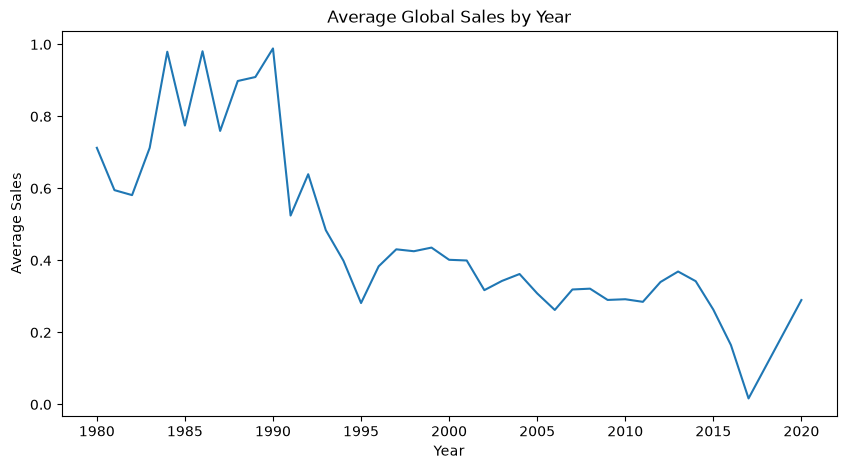

In [20]:
avg_year = df.groupby("Year")["Global_Sales"].mean()

plt.figure(figsize=(10,5))

avg_year.plot()

plt.ylabel("Average Sales")

plt.title("Average Global Sales by Year")

plt.show()

Average Sales by Year and Genre

In [21]:
avg_year_genre = (
    df.groupby(["Year","Genre"])["Global_Sales"]
    .mean()
    .reset_index()
)

print(avg_year_genre.head(20))

      Year       Genre  Global_Sales
0   1980.0      Action      0.340000
1   1980.0    Fighting      0.770000
2   1980.0        Misc      0.661250
3   1980.0     Shooter      1.085000
4   1980.0      Sports      0.490000
5   1981.0      Action      0.513600
6   1981.0    Platform      1.046667
7   1981.0      Puzzle      0.837500
8   1981.0      Racing      0.480000
9   1981.0     Shooter      0.800500
10  1981.0  Simulation      0.450000
11  1981.0      Sports      0.197500
12  1982.0      Action      0.362222
13  1982.0        Misc      0.870000
14  1982.0    Platform      0.902000
15  1982.0      Puzzle      0.916667
16  1982.0      Racing      0.737500
17  1982.0     Shooter      0.751000
18  1982.0      Sports      0.525000
19  1983.0      Action      0.408571


Top Genre

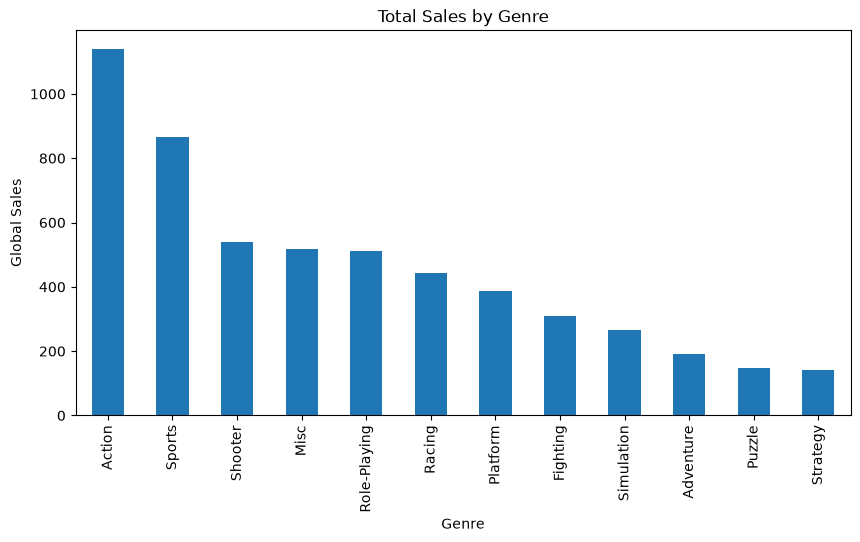

In [22]:
genre_sales = (
    df.groupby("Genre")["Global_Sales"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))

genre_sales.plot(kind='bar')

plt.ylabel("Global Sales")

plt.title("Total Sales by Genre")

plt.show()

Correlation Heatmap

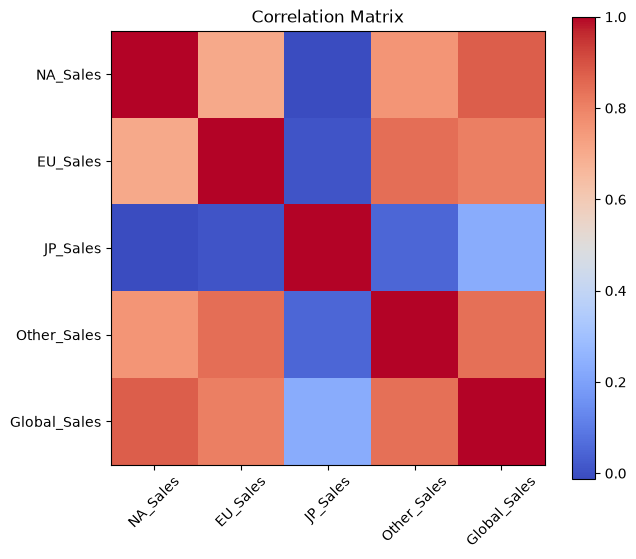

In [23]:
corr = df[sales_cols].corr()

plt.figure(figsize=(7,6))
plt.imshow(corr, cmap='coolwarm', interpolation='nearest')
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Matrix")
plt.show()

Save cleaned dataset

In [24]:
df.to_csv("VG_Sales_Cleaned.csv", index=False)